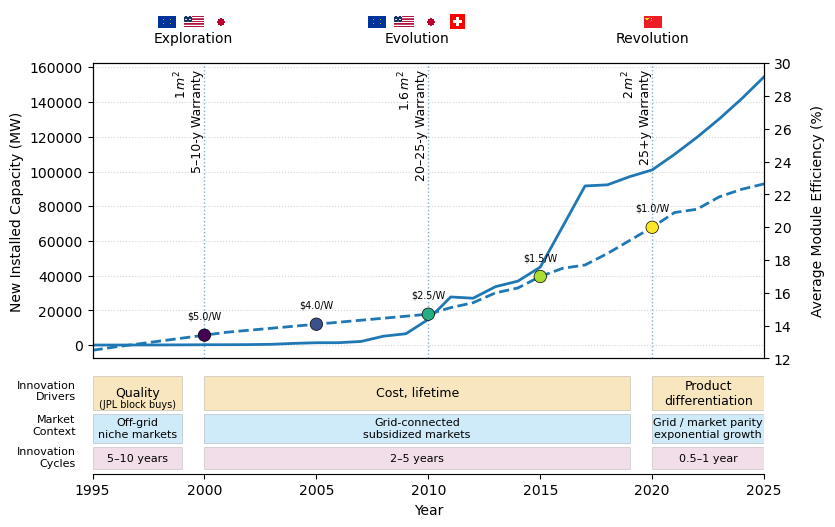

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# User settings
# ----------------------------
xlsx_path = "Repowering_Visual.xlsx"

# --- Band colors (explicit, non-blue, pale) ---
# (Your comment said green, but the hex is sky-blue; keeping your hex values.)
COLOR_DRIVERS = "#E69F00"  # amber
COLOR_MARKET  = "#56B4E9"  # sky blue
COLOR_CYCLES  = "#CC79A7"  # purple

tech_phases = [
    ("Exploration", 1995, 2004),
    ("Evolution",   2005, 2014),
    ("Revolution",  2015, 2025),
]
phase_markers = [2005, 2015]

# --- Timeline tracks ---
innovation_drivers = [
    ("Quality", "(JPL block buys)", 1980, 1999),
    ("Cost, lifetime", "", 2000, 2019),
    ("Product\ndifferentiation", "", 2020, 2100),
]

market_context = [
    ("Off-grid\nniche markets", 1980, 1999),
    ("Grid-connected\nsubsidized markets", 2000, 2019),
    ("Grid / market parity\nexponential growth", 2020, 2100),
]

cost_labels = {
    2000: "$1\\,m^2$\n5–10-y Warranty",
    2010: "$1.6\\,m^2$\n20–25-y Warranty",
    2020: "$2\\,m^2$\n25+y Warranty",
}


# Cost points for colored circles along efficiency line ($/W values)
cost_points = {
    2000: 5.0,
    2005: 4.0,
    2010: 2.5,
    2015: 1.5,
    2020: 1.0,
}

# ----------------------------
# Load data
# ----------------------------
df = pd.read_excel(xlsx_path)
df["year"] = pd.to_numeric(df["year"])
df = df.sort_values("year")

xmin, xmax = df["year"].min(), df["year"].max()

# ----------------------------
# Figure layout (wider)
# ----------------------------
fig, (ax1, ax_band) = plt.subplots(
    nrows=2,
    figsize=(9.2, 5.4),
    sharex=True,
    gridspec_kw={"height_ratios": [6, 2.1], "hspace": 0.06}
)

# ----------------------------
# Main plot
# ----------------------------
ax1.plot(df["year"], df["new_Installed_Capacity_[MW]"], linewidth=2)
ax1.set_ylabel("New Installed Capacity (MW)")
ax1.set_xlim(xmin, xmax)
ax1.grid(True, axis="y", linestyle=":", alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(df["year"], df["average_module_efficiency"], linestyle="--", linewidth=2)
ax2.set_ylabel("Average Module Efficiency (%)")
ax2.set_ylim(12, 30)
# Move secondary y-label slightly inward so the colorbar can sit on the far right
ax2.yaxis.set_label_coords(1.07, 0.5)

# Phase boundaries
'''
for yr in phase_markers:
    if xmin <= yr <= xmax:
        ax1.axvline(yr, linestyle="--", linewidth=1, alpha=0.7)
'''

# Phase labels ABOVE plot
phase_label_y = 1.06
for label, start, end in tech_phases:
    s = max(start, xmin)
    e = min(end, xmax)
    if s < e:
        ax1.text(
            (s + e) / 2,
            phase_label_y,
            label,
            transform=ax1.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=10,
            clip_on=False
        )

# Cost callouts (vertical text near top inside plot)
for yr, txt in cost_labels.items():
    if xmin <= yr <= xmax:
        ax1.axvline(yr, linestyle=":", linewidth=1, alpha=0.6)
        ax1.text(
            yr, 0.98, txt,
            transform=ax1.get_xaxis_transform(),
            rotation=90,
            ha="right",
            va="top",
            fontsize=9
        )

# Reduce x clutter on main plot (x ticks/labels only on timeline subplot)
ax1.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

# ----------------------------
# Timeline subplot (3 tracks)
# ----------------------------
ax_band.set_ylim(0, 1)
ax_band.set_yticks([])
ax_band.set_xlabel("Year")

for spine in ["top", "right", "left"]:
    ax_band.spines[spine].set_visible(False)

ax_band.set_facecolor("white")

# Left labels
x_pad = (xmax - xmin) * 0.025
ax_band.text(xmin - x_pad, 0.80, "Innovation\nDrivers", ha="right", va="center", fontsize=8, clip_on=False)
ax_band.text(xmin - x_pad, 0.47, "Market\nContext",     ha="right", va="center", fontsize=8, clip_on=False)
ax_band.text(xmin - x_pad, 0.16, "Innovation\nCycles",  ha="right", va="center", fontsize=8, clip_on=False)

# Track vertical extents
driver_ymin, driver_ymax = 0.62, 0.95
market_ymin, market_ymax = 0.30, 0.58
cycle_ymin,  cycle_ymax  = 0.05, 0.26

# Optional: add subtle borders to boxes so pale colors still read when printed
BOX_EDGE = "0.35"
BOX_LW = 0.6

# --- Innovation Drivers (amber) ---
for main_label, sub_label, start, end in innovation_drivers:
    s, e = max(start, xmin), min(end, xmax)
    if s < e:
        ax_band.axvspan(
            s, e,
            ymin=driver_ymin, ymax=driver_ymax,
            facecolor=COLOR_DRIVERS, alpha=0.25,
            edgecolor=BOX_EDGE, linewidth=BOX_LW
        )
        xmid = (s + e) / 2
        ax_band.text(xmid, 0.78, main_label, ha="center", va="center", fontsize=9)
        if sub_label:
            ax_band.text(xmid, 0.67, sub_label, ha="center", va="center", fontsize=7)

# --- Market Context (sky blue) ---
for label, start, end in market_context:
    s, e = max(start, xmin), min(end, xmax)
    if s < e:
        ax_band.axvspan(
            s, e,
            ymin=market_ymin, ymax=market_ymax,
            facecolor=COLOR_MARKET, alpha=0.28,
            edgecolor=BOX_EDGE, linewidth=BOX_LW
        )
        ax_band.text((s + e) / 2, 0.44, label, ha="center", va="center", fontsize=8)

# --- Innovation Cycles (purple) ---
for label, start, end in innovation_cycles:
    s, e = max(start, xmin), min(end, xmax)
    if s < e:
        ax_band.axvspan(
            s, e,
            ymin=cycle_ymin, ymax=cycle_ymax,
            facecolor=COLOR_CYCLES, alpha=0.24,
            edgecolor=BOX_EDGE, linewidth=BOX_LW
        )
        ax_band.text((s + e) / 2, 0.15, label, ha="center", va="center", fontsize=8)

# ----------------------------
# Colored circles on efficiency line (encode $/W)
# ----------------------------
cost_years = list(cost_points.keys())
cost_values = list(cost_points.values())

# Ensure years exist in df (avoid index errors)
missing = [y for y in cost_years if y not in set(df["year"].values)]
if missing:
    raise ValueError(f"These cost_years are not present in the data: {missing}")

eff_values = [
    df.loc[df["year"] == y, "average_module_efficiency"].values[0]
    for y in cost_years
]

sc = ax2.scatter(
    cost_years,
    eff_values,
    c=cost_values,
    cmap="viridis_r",
    s=80,
    edgecolors="black",
    linewidth=0.5,
    zorder=5
)

# Colorbar: attach to secondary axis, and give it enough pad so it doesn't collide
'''
cbar = plt.colorbar(
    sc,
    ax=ax2,
    pad=0.07,
    fraction=0.045
)
cbar.set_label("Module cost ($/W)", fontsize=9)
cbar.ax.tick_params(labelsize=8)

'''
# Optional: label each point (can get busy; delete this loop if you want cleaner)
for x, y, cost in zip(cost_years, eff_values, cost_values):
    ax2.annotate(
        f"${cost}/W",
        xy=(x, y),
        xytext=(0, 10),            # 10 points above the marker
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=7
    )

## FLAGS
'''
from matplotlib.font_manager import FontProperties
import os

# --- Use actual emoji flags here ---
phase_flags = {
    "Exploration": "🇪🇺 🇺🇸 🇯🇵",
    "Evolution":   "🇪🇺 🇺🇸 🇯🇵 🇨🇳",
    "Revolution":  "🇨🇭",
}

# --- Force Windows emoji font by file path (most reliable) ---
emoji_font_path = r"C:\Windows\Fonts\seguiemj.ttf"
emoji_fp = FontProperties(fname=emoji_font_path) if os.path.exists(emoji_font_path) else None

# --- Draw flags above phase labels ---
flag_y = 1.12
for label, start, end in tech_phases:
    s = max(start, xmin)
    e = min(end, xmax)
    if s < e and label in phase_flags:
        kwargs = {}
        if emoji_fp is not None:
            kwargs["fontproperties"] = emoji_fp
        else:
            # fallback if font missing
            phase_flags[label] = phase_flags[label].replace("🇪🇺", "EU").replace("🇺🇸","US").replace("🇯🇵","JP").replace("🇨🇳","CN").replace("🇨🇭","CH")

        ax1.text(
            (s + e) / 2,
            flag_y,
            phase_flags[label],
            transform=ax1.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=10,
            clip_on=False,
            **kwargs
        )
'''
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

def add_flag(ax, x, y, image_path, zoom=0.04):
    img = mpimg.imread(image_path)
    imagebox = OffsetImage(img, zoom=zoom)
    ab = AnnotationBbox(
        imagebox,
        (x, y),
        xycoords=ax.get_xaxis_transform(),  # x=data, y=axes fraction
        frameon=False
    )
    ax.add_artist(ab)

phase_flag_files = {
    "Exploration": ["flags/EU.png", "flags/US.png", "flags/JP.png"],
    "Evolution":   ["flags/EU.png", "flags/US.png", "flags/JP.png", "flags/CH.png"],
    "Revolution":  ["flags/CN.png"],
}

flag_y = 1.14        # vertical position above plot
flag_dx = 1.2        # horizontal spacing in *years*

for label, start, end in tech_phases:
    if label not in phase_flag_files:
        continue

    s = max(start, xmin)
    e = min(end, xmax)
    if s >= e:
        continue

    x_center = (s + e) / 2
    flags = phase_flag_files[label]

    # Center flags around the phase midpoint
    n = len(flags)
    x_offsets = [(i - (n - 1) / 2) * flag_dx for i in range(n)]

    for dx, flag_path in zip(x_offsets, flags):
        add_flag(ax1, x_center + dx, flag_y, flag_path, zoom=0.045)






# ----------------------------
# Layout (avoid tight_layout with twinx + colorbar)
# ----------------------------
plt.subplots_adjust(left=0.17, top=0.88, bottom=0.12)
plt.show()


In [ ]:
# Module Size

#Data NLRChampionEfficiency
NLRCE_Year = [1994
2007
2009
2012
2015
2023
2024
2024
2025

NLRCE_Efficiency = 21.8
20.3
21.4
22.4
22.8
24.2
24.9
25.4
26.0

NLRCE_Area = 
862
16300.00
15780.00
15775.00
15738.90
18252.50
17753.40
25410.00
18155.00


NLRCE_Power = 
18.8
330.9
337.7
353.4
358.8
441.7
442.1
645.4
472.0


# YUAN 2024 Dta
Yuan_Year = [2006
2007
2008
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2021
2022
2024
2026
2029
2032

Yuan_Area = [1.26
1.41
1.46
1.69
1.53
1.70
1.69
1.63
1.67
1.75
1.72
1.84
1.79
1.86
1.97
2.19
2.32
2.49
2.58
2.62
2.65

ITRPV_Year = [2021
2022
2024
2026
2029
2032

ITRPV_Area = [2.77
2.79
2.82
2.83
2.84
2.84



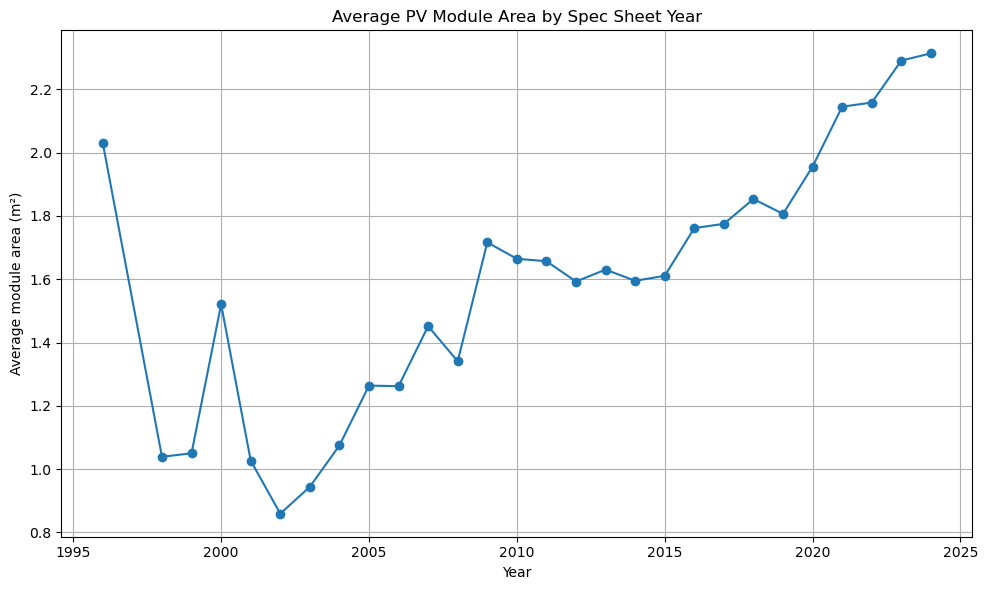

,year,module_area_m2
0,1996,2.029847
1,1998,1.039096
2,1999,1.050155
3,2000,1.520950
4,2001,1.027243
5,2002,0.859228
6,2003,0.944278
7,2004,1.074797
8,2005,1.264000
9,2006,1.262178


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# File in same folder as the notebook
file_path = "Module Size Data and True Cost Mini-Analysis.xlsx"
sheet_name = "ModuleSize Pordis&Smith2024"

# Read sheet
df = pd.read_excel(file_path, sheet_name=sheet_name)

# Parse the spec sheet date column
df["spec_sheet_date"] = pd.to_datetime(df["spec_sheet_date"], errors="coerce")

# Keep only rows with a valid date and valid module area
df_plot = df.dropna(subset=["spec_sheet_date", "module_area_m2"]).copy()

# Extract year
df_plot["year"] = df_plot["spec_sheet_date"].dt.year

# Average module area by year
yearly_avg = (
    df_plot.groupby("year", as_index=False)["module_area_m2"]
    .mean()
    .sort_values("year")
)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(yearly_avg["year"], yearly_avg["module_area_m2"], marker="o")
plt.xlabel("Year")
plt.ylabel("Average module area (m²)")
plt.title("Average PV Module Area by Spec Sheet Year")
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: display the table too
yearly_avg

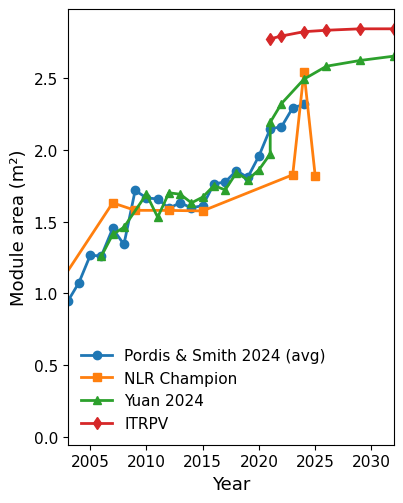

In [8]:
import matplotlib.pyplot as plt

# ----------------------------
# Styling (bigger fonts + square-ish figure)
# ----------------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

# Slightly taller than wide (good for 1-column figures)
plt.figure(figsize=(4.2, 5.2))

# ----------------------------
# Plot
# ----------------------------
plt.plot(
    yearly_avg["year"],
    yearly_avg["module_area_m2"],
    marker="o",
    linewidth=2,
    label="Pordis & Smith 2024 (avg)"
)

plt.plot(
    NLRCE_Year,
    NLRCE_Area_m2,
    marker="s",
    linewidth=2,
    label="NLR Champion"
)

plt.plot(
    Yuan_Year,
    Yuan_Area,
    marker="^",
    linewidth=2,
    label="Yuan 2024"
)

plt.plot(
    ITRPV_Year,
    ITRPV_Area,
    marker="d",
    linewidth=2,
    label="ITRPV"
)

# ----------------------------
# Axes / layout
# ----------------------------
plt.xlim(2003, 2032)
plt.xlabel("Year")
plt.ylabel("Module area (m²)")

plt.grid(False)
plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    "module_area_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


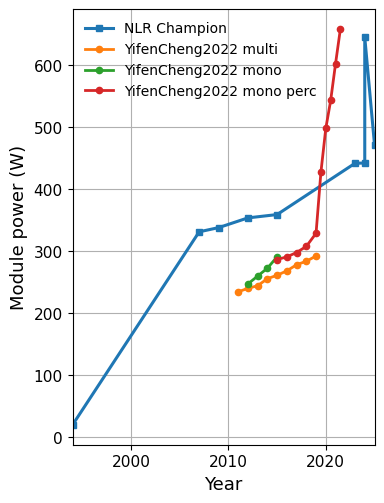

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1. Read YifenCheng2022 sheet
# ----------------------------
file_path = "Module Size Data and True Cost Mini-Analysis.xlsx"
sheet_name = "Digitized_YifenCheng2022"

df_y = pd.read_excel(file_path, sheet_name=sheet_name)

# Keep only needed columns and valid rows
df_y = df_y[["Year", "Power", "Technology"]].copy()
df_y["Year"] = pd.to_numeric(df_y["Year"], errors="coerce")
df_y["Power"] = pd.to_numeric(df_y["Power"], errors="coerce")
df_y["Technology"] = df_y["Technology"].astype(str).str.strip().str.lower()

df_y = df_y.dropna(subset=["Year", "Power", "Technology"])

# Optional: standardize a few likely technology labels
df_y["Technology"] = df_y["Technology"].replace({
    "monoperc": "mono perc",
    "mono perc.": "mono perc",
    "mono-perc": "mono perc",
    "monocrystalline": "mono",
    "poly": "multi",
    "poly-si": "multi",
    "multicrystalline": "multi",
})

# Keep only the 3 traces of interest
tech_keep = ["multi", "mono", "mono perc"]
df_y = df_y[df_y["Technology"].isin(tech_keep)].copy()

# Average power by Year and Technology
yifen_avg = (
    df_y.groupby(["Year", "Technology"], as_index=False)["Power"]
    .mean()
    .sort_values(["Technology", "Year"])
)

# ----------------------------
# 2. NLR dataset
# ----------------------------
NLRCE_Year = [1994, 2007, 2009, 2012, 2015, 2023, 2024, 2024, 2025]
NLRCE_Power = [18.8, 330.9, 337.7, 353.4, 358.8, 441.7, 442.1, 645.4, 472.0]

# ----------------------------
# 3. Styling
# ----------------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

plt.figure(figsize=(4.2, 5.2))

# ----------------------------
# 4. Plot NLR first
# ----------------------------
plt.plot(
    NLRCE_Year,
    NLRCE_Power,
    marker="s",
    linewidth=2.2,
    markersize=5,
    label="NLR Champion"
)

# ----------------------------
# 5. Plot Yifen traces
# ----------------------------
for tech, label in [
    ("multi", "YifenCheng2022 multi"),
    ("mono", "YifenCheng2022 mono"),
    ("mono perc", "YifenCheng2022 mono perc"),
]:
    sub = yifen_avg[yifen_avg["Technology"] == tech]
    plt.plot(
        sub["Year"],
        sub["Power"],
        marker="o",
        linewidth=2,
        markersize=4.5,
        label=label
    )

# ----------------------------
# 6. Axes / layout
# ----------------------------
plt.xlabel("Year")
plt.ylabel("Module power (W)")
plt.xlim(1994, max(yifen_avg["Year"].max(), max(NLRCE_Year)))
plt.grid(True)
plt.legend(frameon=False)
plt.tight_layout()

# Save at 300 dpi
plt.savefig("module_power_by_technology.png", dpi=300, bbox_inches="tight")

plt.show()

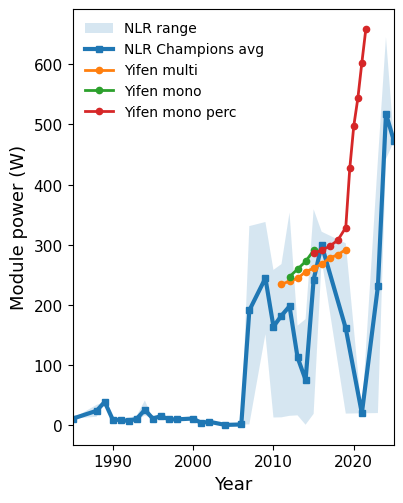

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1. Read YifenCheng2022
# ----------------------------
file_path = "Module Size Data and True Cost Mini-Analysis.xlsx"

df_y = pd.read_excel(file_path, sheet_name="Digitized_YifenCheng2022")
df_y = df_y[["Year", "Power", "Technology"]].copy()

df_y["Year"] = pd.to_numeric(df_y["Year"], errors="coerce")
df_y["Power"] = pd.to_numeric(df_y["Power"], errors="coerce")
df_y["Technology"] = df_y["Technology"].astype(str).str.strip().str.lower()

df_y = df_y.dropna(subset=["Year", "Power", "Technology"])

df_y["Technology"] = df_y["Technology"].replace({
    "monoperc": "mono perc",
    "mono-perc": "mono perc",
    "mono perc.": "mono perc",
    "monocrystalline": "mono",
    "poly": "multi",
    "poly-si": "multi",
    "multicrystalline": "multi",
})

tech_keep = ["multi", "mono", "mono perc"]
df_y = df_y[df_y["Technology"].isin(tech_keep)].copy()

yifen_avg = (
    df_y.groupby(["Year", "Technology"], as_index=False)["Power"]
    .mean()
    .sort_values(["Technology", "Year"])
)

# ----------------------------
# 2. Read NLR Champions tab
# ----------------------------
df_nlr = pd.read_excel(file_path, sheet_name="ModuleSize NLR Champions Table")

# Adjust these names if needed after checking df_nlr.columns
# Expected columns something like: Year, Power, Technology
df_nlr = df_nlr[["Year", "Module Power", "Cell Type (cell material, junctions, concent)"]].copy()

df_nlr["Year"] = pd.to_numeric(df_nlr["Year"], errors="coerce")
df_nlr["Power"] = pd.to_numeric(df_nlr["Module Power"], errors="coerce")
df_nlr["Technology"] = df_nlr["Cell Type (cell material, junctions, concent)"].astype(str).str.strip()

df_nlr = df_nlr.dropna(subset=["Year", "Power"])

# Average NLR power by year
nlr_avg = (
    df_nlr.groupby("Year", as_index=False)["Power"]
    .mean()
    .sort_values("Year")
)

# Optional range for a band (shows spread across technologies in same year)
nlr_range = (
    df_nlr.groupby("Year")["Power"]
    .agg(["min", "max"])
    .reset_index()
    .sort_values("Year")
)

# Optional max-only version if you decide to use record instead
nlr_max = (
    df_nlr.groupby("Year", as_index=False)["Power"]
    .max()
    .sort_values("Year")
)

# ----------------------------
# 3. Plot styling
# ----------------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

plt.figure(figsize=(4.2, 5.2))

# ----------------------------
# 4. NLR average line + optional band
# ----------------------------
plt.fill_between(
    nlr_range["Year"],
    nlr_range["min"],
    nlr_range["max"],
    alpha=0.18,
    label="NLR range"
)

plt.plot(
    nlr_avg["Year"],
    nlr_avg["Power"],
    marker="s",
    linewidth=3.0,   # thicker line
    markersize=5,
    label="NLR Champions avg"
)

# ----------------------------
# 5. Yifen traces
# ----------------------------
for tech, label in [
    ("multi", "Yifen multi"),
    ("mono", "Yifen mono"),
    ("mono perc", "Yifen mono perc"),
]:
    sub = yifen_avg[yifen_avg["Technology"] == tech]
    plt.plot(
        sub["Year"],
        sub["Power"],
        marker="o",
        linewidth=2,
        markersize=4.5,
        label=label
    )

# ----------------------------
# 6. Axes / layout
# ----------------------------
xmin = min(nlr_avg["Year"].min(), yifen_avg["Year"].min())
xmax = max(nlr_avg["Year"].max(), yifen_avg["Year"].max())

plt.xlim(xmin, xmax)
plt.xlabel("Year")
plt.ylabel("Module power (W)")
plt.grid(False)
plt.legend(frameon=False)
plt.tight_layout()

plt.savefig("module_power_yifen_nlr_avg.png", dpi=300, bbox_inches="tight")
plt.show()

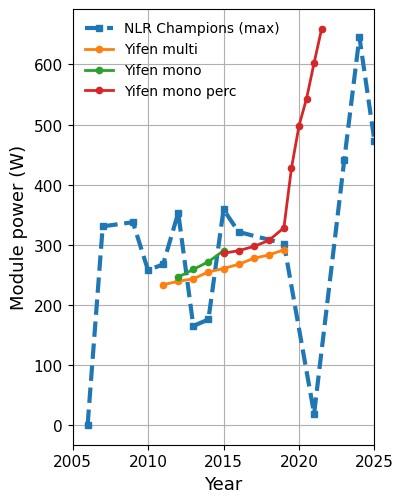

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "Module Size Data and True Cost Mini-Analysis.xlsx"

# ----------------------------
# 1. Yifen data
# ----------------------------
df_y = pd.read_excel(file_path, sheet_name="Digitized_YifenCheng2022")

df_y = df_y[["Year", "Power", "Technology"]].copy()

df_y["Year"] = pd.to_numeric(df_y["Year"], errors="coerce")
df_y["Power"] = pd.to_numeric(df_y["Power"], errors="coerce")
df_y["Technology"] = df_y["Technology"].astype(str).str.strip().str.lower()

df_y = df_y.dropna(subset=["Year", "Power", "Technology"])

# normalize labels
df_y["Technology"] = df_y["Technology"].replace({
    "monoperc": "mono perc",
    "mono-perc": "mono perc",
    "mono perc.": "mono perc",
    "monocrystalline": "mono",
    "poly": "multi",
    "poly-si": "multi",
    "multicrystalline": "multi",
})

tech_keep = ["multi", "mono", "mono perc"]
df_y = df_y[df_y["Technology"].isin(tech_keep)].copy()

# average per tech per year
yifen_avg = (
    df_y.groupby(["Year", "Technology"], as_index=False)["Power"]
    .mean()
    .sort_values(["Technology", "Year"])
)

# ----------------------------
# 2. NLR Champions (MAX per year)
# ----------------------------
df_nlr = pd.read_excel(file_path, sheet_name="ModuleSize NLR Champions Table")

df_nlr = df_nlr[["Year", "Module Power"]].copy()

df_nlr["Year"] = pd.to_numeric(df_nlr["Year"], errors="coerce")
df_nlr["Module Power"] = pd.to_numeric(df_nlr["Module Power"], errors="coerce")

df_nlr = df_nlr.dropna(subset=["Year", "Module Power"])

nlr_max = (
    df_nlr.groupby("Year", as_index=False)["Module Power"]
    .max()
    .sort_values("Year")
)

# ----------------------------
# 3. Filter to start at 2005
# ----------------------------
yifen_avg = yifen_avg[yifen_avg["Year"] >= 2005]
nlr_max = nlr_max[nlr_max["Year"] >= 2005]

# ----------------------------
# 4. Styling
# ----------------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

plt.figure(figsize=(4.2, 5.2))

# ----------------------------
# 5. Plot NLR (frontier)
# ----------------------------
plt.plot(
    nlr_max["Year"],
    nlr_max["Module Power"],
    marker="s",
    linewidth=3.0,
    markersize=5,
    linestyle="--",
    label="NLR Champions (max)"
)

# ----------------------------
# 6. Plot Yifen
# ----------------------------
for tech, label in [
    ("multi", "Yifen multi"),
    ("mono", "Yifen mono"),
    ("mono perc", "Yifen mono perc"),
]:
    sub = yifen_avg[yifen_avg["Technology"] == tech]
    plt.plot(
        sub["Year"],
        sub["Power"],
        marker="o",
        linewidth=2,
        markersize=4.5,
        label=label
    )

# ----------------------------
# 7. Layout
# ----------------------------
xmin = 2005
xmax = max(yifen_avg["Year"].max(), nlr_max["Year"].max())

plt.xlim(xmin, xmax)
plt.xlabel("Year")
plt.ylabel("Module power (W)")
plt.grid(True)
plt.legend(frameon=False)

plt.tight_layout()
plt.savefig("module_power_frontier.png", dpi=300, bbox_inches="tight")
plt.show()

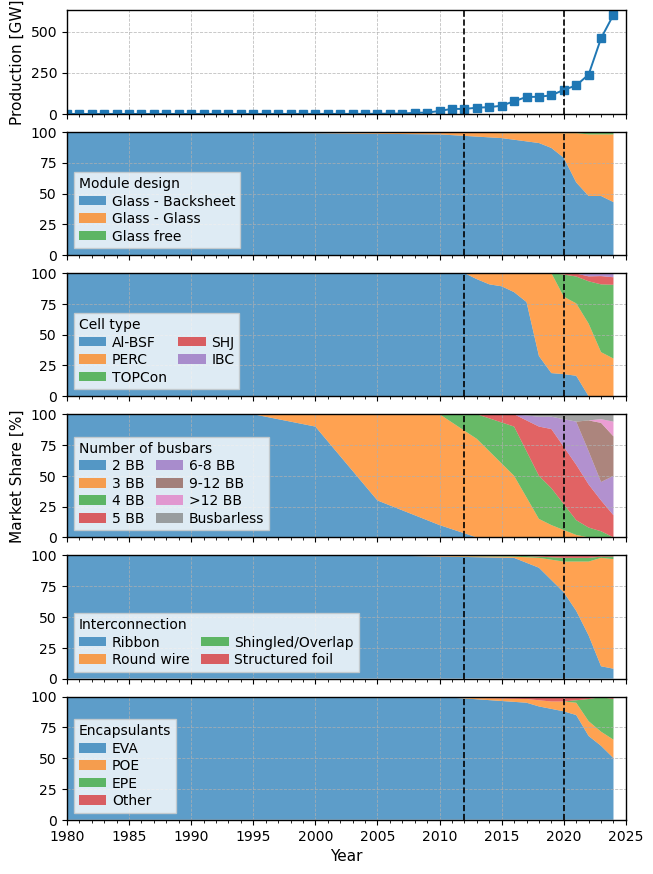

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# =========================================================
# SETTINGS
# =========================================================
file_path = "Market Shares.xlsx"

# Figure sized to fit ~85% of a full text-page width,
# while leaving room below for a 4–5 line caption
FIG_WIDTH = 6.5   # inches
FIG_HEIGHT = 9.0  # inches

# Keep axis to 2025, but stop plotting real data at 2024
PLOT_END_YEAR = 2024
AXIS_END_YEAR = 2025

# Vertical dashed reference lines
ref_years = [2012, 2020]

# =========================================================
# 1. READ RAW EXCEL AND REBUILD HEADERS
# =========================================================
raw = pd.read_excel(file_path, header=None)

# First 4 rows are headers
header_rows = raw.iloc[:4].copy()
data = raw.iloc[4:].copy()

# Fill merged header cells horizontally
header_rows = header_rows.ffill(axis=1)

def clean(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s.lower().startswith("unnamed"):
        return ""
    return s

# Build flattened column names from 4 header rows
flat_cols = []
for col_idx in range(raw.shape[1]):
    parts = [clean(header_rows.iloc[r, col_idx]) for r in range(4)]
    parts = [p for p in parts if p != ""]
    flat_cols.append(" | ".join(parts))

data.columns = flat_cols
data = data.reset_index(drop=True)

# Uncomment to inspect headers if needed
# for c in data.columns:
#     print(c)

# =========================================================
# 2. HELPERS TO FIND COLUMNS
# =========================================================
def find_col_contains_all(cols, terms):
    terms = [t.lower() for t in terms]
    for c in cols:
        cl = c.lower()
        if all(t in cl for t in terms):
            return c
    return None

def find_col_last_part(cols, label):
    label = label.lower().strip()
    for c in cols:
        parts = [p.strip().lower() for p in c.split("|")]
        if parts and parts[-1] == label:
            return c
    return None

# =========================================================
# 3. EXTRACT DATA
# =========================================================
year_col = find_col_last_part(data.columns, "Year")
prod_col = find_col_contains_all(data.columns, ["production", "[gw]"])

# Make sure we did not accidentally grab cumulative shipments
if prod_col is not None and "cumulative" in prod_col.lower():
    for c in data.columns:
        parts = [p.strip().lower() for p in c.split("|")]
        if parts and parts[-1] == "production" and "[gw]" in c.lower():
            prod_col = c
            break

df = pd.DataFrame()
df["Year"] = pd.to_numeric(data[year_col], errors="coerce")
df["Production"] = pd.to_numeric(data[prod_col], errors="coerce")

share_labels = [
    "Al-BSF", "PERC", "TOPCon", "SHJ", "IBC",
    "Glass - Backsheet", "Glass - Glass", "Glass free",
    "EVA", "POE", "EPE", "Other",
    "2 BB", "3 BB", "4 BB", "5 BB", "6-8 BB", "9-12 BB", ">12 BB", "Busbarless",
    "Ribbon", "Round wire", "Shingled/Overlap", "Structured foil"
]

for label in share_labels:
    col = find_col_last_part(data.columns, label)
    if col is not None:
        df[label] = pd.to_numeric(data[col], errors="coerce")
    else:
        print(f"Missing: {label}")

df = df.dropna(subset=["Year"]).copy()
df["Year"] = df["Year"].astype(int)
df = df.sort_values("Year")

# =========================================================
# 4. DEFINE GROUPS
# =========================================================
cell_type = ["Al-BSF", "PERC", "TOPCon", "SHJ", "IBC"]
module_design = ["Glass - Backsheet", "Glass - Glass", "Glass free"]
encapsulant = ["EVA", "POE", "EPE", "Other"]
busbars = ["2 BB", "3 BB", "4 BB", "5 BB", "6-8 BB", "9-12 BB", ">12 BB", "Busbarless"]
interconnection = ["Ribbon", "Round wire", "Shingled/Overlap", "Structured foil"]

share_cols = cell_type + module_design + encapsulant + busbars + interconnection

# Plot only through 2024, but keep axis to 2025
plot_df = df[
    (df["Year"] <= PLOT_END_YEAR) &
    (
        df["Production"].notna() |
        df[share_cols].notna().any(axis=1)
    )
].copy()

# =========================================================
# 5. PLOT STYLING
# =========================================================
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, axes = plt.subplots(
    6, 1,
    figsize=(FIG_WIDTH, FIG_HEIGHT),
    sharex=True,
    gridspec_kw={"height_ratios": [1.1, 1.3, 1.3, 1.3, 1.3, 1.3]}
)

# =========================================================
# 6. TOP PANEL: PRODUCTION
# =========================================================
axes[0].plot(plot_df["Year"], plot_df["Production"], marker="s", linewidth=1.4)
axes[0].set_ylabel("Production [GW]")
axes[0].set_ylim(bottom=0)
axes[0].grid(True, linestyle="--", linewidth=0.6, alpha=0.8)

# =========================================================
# 7. STACKED AREA HELPER
# =========================================================
def stacked_panel(ax, categories, title, ncol=1):
    existing = [c for c in categories if c in plot_df.columns]
    vals = plot_df[existing].fillna(0).T.values

    ax.stackplot(plot_df["Year"], vals, labels=existing, alpha=0.72)
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.8)

    leg = ax.legend(
        loc="lower left",
        ncol=ncol,
        frameon=True,
        fancybox=False,
        borderpad=0.35,
        labelspacing=0.25,
        handletextpad=0.4,
        columnspacing=0.8,
        title=title
    )
    leg._legend_box.align = "left"
# =========================================================
# 8. STACKED PANELS
# =========================================================
stacked_panel(axes[1], module_design, "Module design")
stacked_panel(axes[2], cell_type, "Cell type", ncol=2)   # 👈 THIS ONE
stacked_panel(axes[3], busbars, "Number of busbars", ncol=2)
stacked_panel(axes[4], interconnection, "Interconnection", ncol=2)
stacked_panel(axes[5], encapsulant, "Encapsulants")

# =========================================================
# 9. SHARED FORMATTING
# =========================================================
for ax in axes:
    ax.set_xlim(1980, AXIS_END_YEAR)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    for yr in ref_years:
        ax.axvline(yr, color="black", linestyle="--", linewidth=1.2)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

axes[3].set_ylabel("Market Share [%]")
axes[-1].set_xlabel("Year")

plt.tight_layout()

plt.subplots_adjust(
    hspace=0.15,   # vertical spacing between panels
    left=0.12,
    right=0.98,
    top=0.98,
    bottom=0.08
)

# Save both raster and vector
plt.savefig("market_share_subplots.png", dpi=300, bbox_inches="tight")

plt.show()